## FashionMNIST Dataset

- **FashionMNIST** is a dataset of Zalando article images.
- It contains **70,000 images** of size 28x28 pixels.
- The dataset has **10 classes**, each representing a different clothing item:
1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

In [1]:
import matplotlib.pyplot as plt
import torch.optim
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
from torchvision import transforms, datasets

from src.hyper_parameters import HyperParameters
from src.utils import random_pixels
from src.utils.noisy_dataset import NoisyDataset
from src.utils.test_model import vae_test_model_on
from src.utils.train_loop import train_loop_vae
from vae_autoencoder import VAEAutoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
hyper_params = HyperParameters(learning_rate=1e-3, batch_size=128, epochs=10, seed=42)

In [3]:
transform = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ]
)

transform_with_noise = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        random_pixels.RandomPixels(noise_ratio=0.05, seed=hyper_params.seed),
    ]
)

fashion_MINST = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

dataset = NoisyDataset(dataset=fashion_MINST, noise_transform=transform_with_noise)

## Dataset split and DataLoader preparation
- Calculate the total dataset size: dataset_size = len(dataset)
- Split the dataset into:
  - train_dataset – 70% of the data
  - val_dataset – 15% of the data
  - test_dataset – remaining 15% of the data
- Create DataLoaders for each split:
  - batch_size=32
  - shuffle=True for the training set
  - num_workers=4 and pin_memory=True for faster data loading
- Print dataset information:
  - number of samples in each split
  - number of classes
  - list of class names

In [4]:
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

classes_str = ", ".join(f"{cls}" for cls in dataset.classes)
print(f"Training samples: {len(train_dataset)} (70%)")
print(f"Validation samples: {len(val_dataset)} (15%)")
print(f"Test samples: {len(test_dataset)} (15%)")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Classes: {classes_str}")

Training samples: 42000 (70%)
Validation samples: 9000 (15%)
Test samples: 9000 (15%)
Number of classes: 10
Classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


## Display sample images from the training set

- Retrieve a batch of images and labels from the training DataLoader
- Display 10 sample images in a 2x5 grid
- Rearrange tensor from (C, H, W) to (H, W, C) for proper visualization
- Show corresponding class names as titles
- Hide axes for a cleaner look

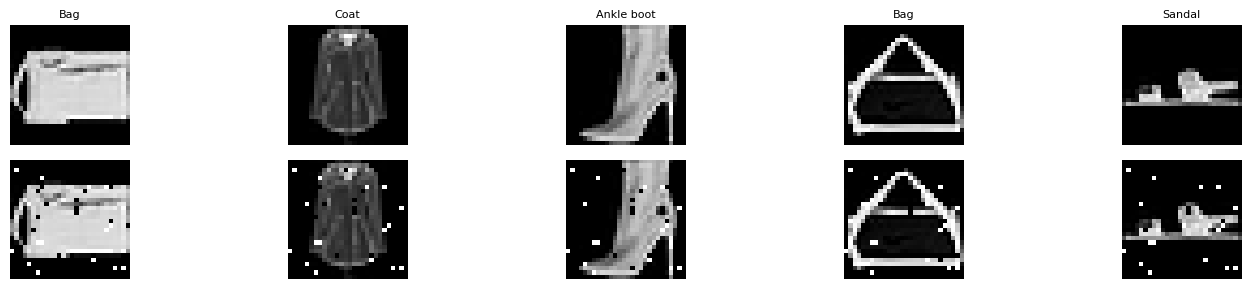

In [5]:
original_images, noisy_images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 3))

for i in range(5):
    img = original_images[i].permute(1, 2, 0)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(dataset.classes[labels[i]], fontsize=8)
    axes[0, i].axis("off")

    noisy_img = noisy_images[i].permute(1, 2, 0)
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Noisy", fontsize=10, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

## Initialize variational autoencoder

In [6]:
model = VAEAutoencoder(latent_dim=10).to(device)

## Set an optimizer

In [7]:
optimizer = torch.optim.Adam(
    lr=hyper_params.learning_rate,
    params=model.parameters(),
    weight_decay=1e-8,
)

## Set loss function

In [8]:
criterion = nn.MSELoss()
criterion.to(device)

MSELoss()

### Train loop with Test/Validation datasets calculations each epoch

In [9]:
train_loss = 0.0
test_losses = []
validation_losses = []
original_images = []
model_reconstructed_images = []

for i in range(hyper_params.epochs):
    curr_loss, original_image, reconstructed_image = train_loop_vae(
        model, train_loader, optimizer, criterion, device
    )
    print(f"Epoch {i + 1}/{hyper_params.epochs}: loss = {curr_loss:.4f}")
    train_loss += curr_loss
    test_loss = vae_test_model_on(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    validation_loss = vae_test_model_on(model, val_loader, criterion, device)
    validation_losses.append(validation_loss)

    original_images.append(original_image.detach().cpu().numpy().squeeze())
    model_reconstructed_images.append(
        reconstructed_image.detach().cpu().numpy().squeeze()
    )

print(f"Training loss: {(train_loss / hyper_params.epochs):.4f}")
print(f"Validation losses: {sum(validation_losses) / hyper_params.epochs:.4f}")
print(f"Test losses: {sum(test_losses) / hyper_params.epochs:.4f}")

Epoch 1/10: loss = 0.0849
Epoch 2/10: loss = 0.0696
Epoch 3/10: loss = 0.0679
Epoch 4/10: loss = 0.0670
Epoch 5/10: loss = 0.0664
Epoch 6/10: loss = 0.0661
Epoch 7/10: loss = 0.0658
Epoch 8/10: loss = 0.0657
Epoch 9/10: loss = 0.0653
Epoch 10/10: loss = 0.0653
Training loss: 0.0684
Validation losses: 0.0494
Test losses: 0.0490


### Sample images regenerated by AutoEncoder

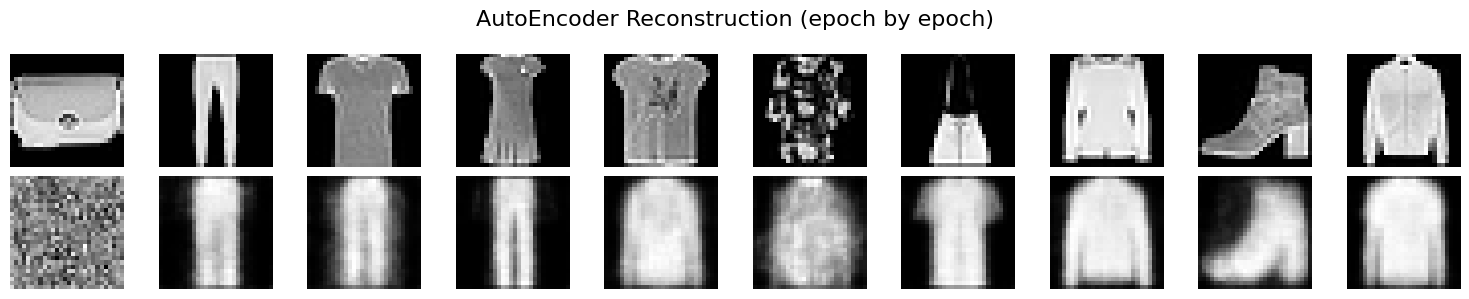

In [10]:
fig, axes = plt.subplots(2, hyper_params.epochs, figsize=(15, 3))

for i in range(hyper_params.epochs):
    img = original_images[i]
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")

    noisy_img = model_reconstructed_images[i]
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle("AutoEncoder Reconstruction (epoch by epoch)", fontsize=16)
plt.tight_layout()
plt.show()

### New sample generation from latent space

In [12]:
n = 10
grid_x = torch.linspace(-3, 3, n)
grid_y = torch.linspace(-3, 3, n)

with torch.no_grad():
    figure = torch.zeros((28 * n, 28 * n))  # "płótno" na 10x10 obrazów

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_hat = model.decode(z)
            img = x_hat[0, 0].cpu()  # [1, 1, 28, 28] -> [28, 28]

            figure[(n - i - 1) * 28 : (n - i) * 28, j * 28 : (j + 1) * 28] = img

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2 and 10x3136)